# Example-23: Envelope and instantaneous frequency

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example DHT is used to compute signal envelope and instantaneous frequency

In [4]:
# Set test signal

length = 8192

t = torch.linspace(1, length, length, dtype=dtype, device=device)
s = torch.exp(-0.0001*t*(1 + 0.25*torch.cos(2*numpy.pi*0.001*t)))*torch.cos(2.0*numpy.pi*0.12345*t).unsqueeze(0)

# Compute DHT

dht = Frequency.dht(s)

# Compute envelope

envelope = dht.abs()

# Compute instantaneous frequency
# Note, length is reduced by one

frequency = 1/(2.0*numpy.pi)*(dht[:, :-1]*dht[:, 1:].conj()).angle()

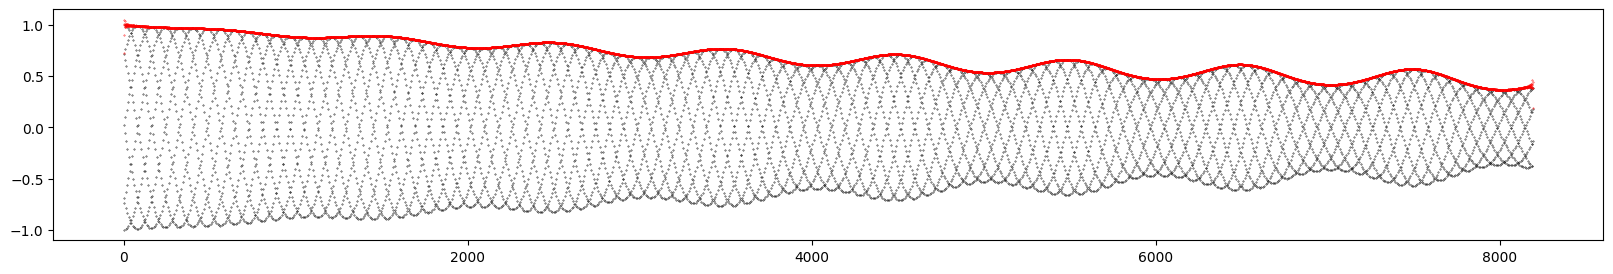

In [5]:
# Plot signal and envelope
# Note, result is not accurate at both ends

plt.figure(figsize=(20 ,3))
plt.scatter(range(length), s[0].cpu().numpy(), c='black', s=0.1)
plt.scatter(range(length), envelope[0].cpu().numpy(), c='red', s=0.1)
plt.show()

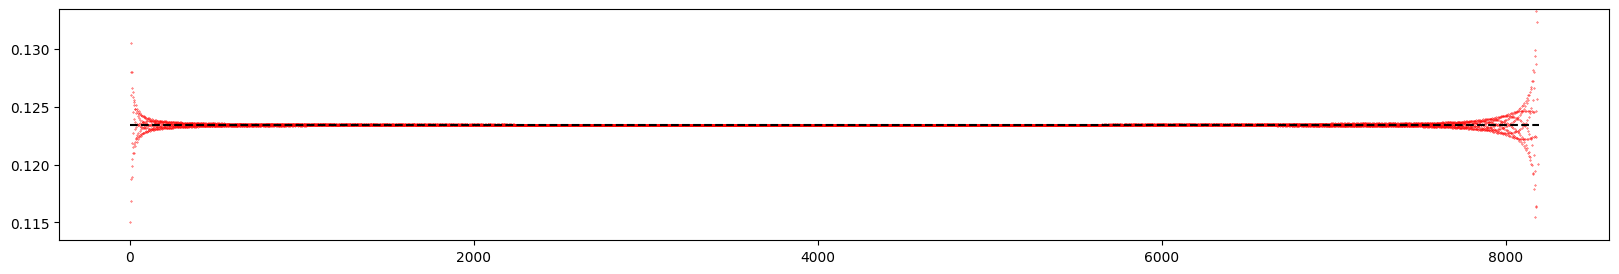

In [6]:
# Plot instantaneous frequency
# Note, result is not accurate at both ends

plt.figure(figsize=(20, 3))
plt.ylim(0.12345-0.01, 0.12345+0.01)
plt.scatter(range(length-1), frequency[0].cpu().numpy(), c='red', s=0.1)
plt.hlines(0.12345, 1, length, color='black', linestyles='dashed')
plt.show()